In [33]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from velocity_model import homogeneous_model
from source import ricker
from SecondOrderAcousticForwardSolver import SecondOrderAcousticForwardSolver

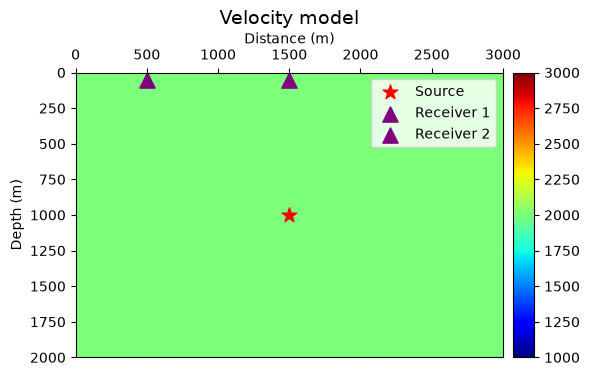

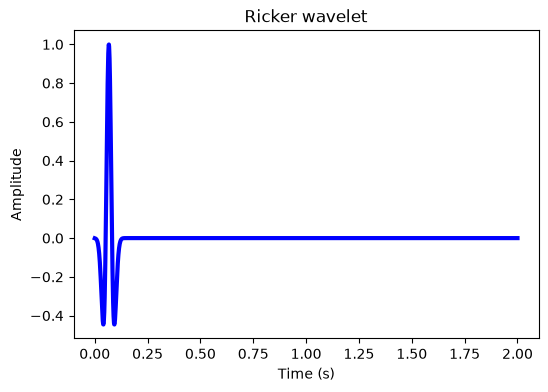

In [ ]:
#-------------------------------------------------------
# Basic parameters
#-------------------------------------------------------
nx = 301
nz = 201
dx = 10
dz = 10
x_max = (nx-1)*dx
z_max = (nz-1)*dz
dt = 0.001
tmax = 2.0
nt = int(tmax / dt) + 1
t = np.arange(nt) * dt
#-------------------------------------------------------
# Source location
#-------------------------------------------------------
iz_src = nz//2
ix_src = nx//2
#-------------------------------------------------------
# Receivers location
#-------------------------------------------------------
iz_receiver = np.array([5,5],dtype=np.int64)
ix_receiver = np.array([50,150],dtype=np.int64)
#-------------------------------------------------------
# Velocity model
#-------------------------------------------------------
velocity = homogeneous_model(nx, nz, 2000)
fig,ax1 = plt.subplots(figsize=(6,6))
im = ax1.imshow(
    velocity,
    cmap='jet',
    extent=[0,x_max,z_max,0],
    vmin=1000.0,
    vmax=3000.0,
)
ax1.scatter(ix_src*dx,iz_src*dz,marker='*',color='red',s=120,label='Source')
ax1.scatter(ix_receiver[0]*dx,iz_receiver[0]*dz,marker='^',color='purple',s=120,label='Receiver 1')
ax1.scatter(ix_receiver[1]*dx,iz_receiver[1]*dz,marker='^',color='purple',s=120,label='Receiver 2')
ax1.xaxis.set_label_position('top')
ax1.xaxis.tick_top()
ax1.set_xlabel('Distance (m)')
ax1.set_ylabel('Depth (m)')
ax1.set_title('Velocity model',fontsize=14)
ax1.legend()
divider = make_axes_locatable(ax1)
cax = divider.append_axes(
    "right",
    size="5%",
    pad=0.10
)
cbar = plt.colorbar(im,cax=cax)
plt.tight_layout()
plt.show()
#-------------------------------------------------------
# Wavelet
#-------------------------------------------------------
f0 = 15.0
t0 = 1.0 / f0
wavelet = ricker(t, f0, t0)
fig,ax2 = plt.subplots(figsize=(6,4))
ax2.plot(t,wavelet,linewidth='3',color='blue')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude')
ax2.set_title('Ricker wavelet')
plt.show()

In [35]:
#-------------------------------------------------------
# Forward modeling
#-------------------------------------------------------
solver = SecondOrderAcousticForwardSolver(
    velocity=velocity,
    dx=dx,
    dz=dz,
    dt=dt,
    order=8,
)
solver.set_source(
    wavelet=wavelet,
    ix=ix_src,
    iz=iz_src,
)
solver.set_receivers(
    ix=ix_receiver,
    iz=iz_receiver,
)
solver.set_boundary(
    boundary_type="pml",
    n_abs=60,
    reflection=1e-6,
    power=2,
)
result = solver.forward(
    snapshot_times=np.array([0.5,0.7,0.9],dtype=np.float64)
)
print(
    "snapshots shape =",
    result.snapshots.shape
)

print(
    "seismogram shape =",
    result.seismogram.shape
)

Time step: 100 / 2001   Time: 0.1 s
Time step: 200 / 2001   Time: 0.2 s
Time step: 300 / 2001   Time: 0.3 s
Time step: 400 / 2001   Time: 0.4 s
Time step: 500 / 2001   Time: 0.5 s
Time step: 600 / 2001   Time: 0.6 s
Time step: 700 / 2001   Time: 0.7000000000000001 s
Time step: 800 / 2001   Time: 0.8 s
Time step: 900 / 2001   Time: 0.9 s
Time step: 1000 / 2001   Time: 1.0 s
Time step: 1100 / 2001   Time: 1.1 s
Time step: 1200 / 2001   Time: 1.2 s
Time step: 1300 / 2001   Time: 1.3 s
Time step: 1400 / 2001   Time: 1.4000000000000001 s
Time step: 1500 / 2001   Time: 1.5 s
Time step: 1600 / 2001   Time: 1.6 s
Time step: 1700 / 2001   Time: 1.7 s
Time step: 1800 / 2001   Time: 1.8 s
Time step: 1900 / 2001   Time: 1.9000000000000001 s
Time step: 2000 / 2001   Time: 2.0 s
snapshots shape = (3, 201, 301)
seismogram shape = (2001, 2)


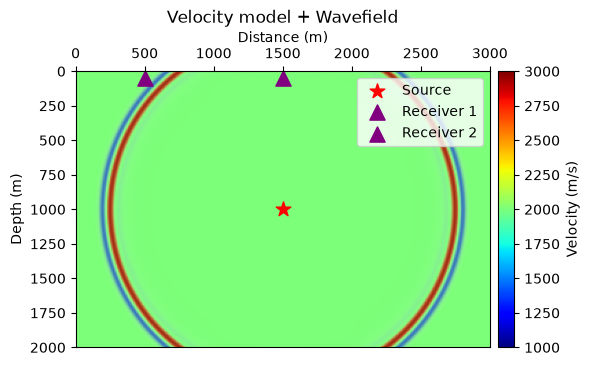

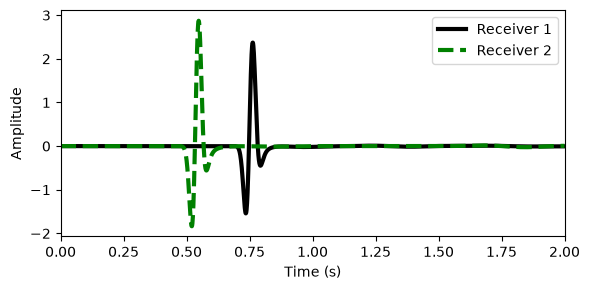

In [36]:
#---------------------------------------------------
# plot
#---------------------------------------------------
snapshots = result.snapshots[1]
vmax = 3
fig, ax3 = plt.subplots(figsize=(6,6))
im1 = ax3.imshow(
    velocity,
    extent=[0,x_max,z_max,0],
    vmin=1000.0,
    vmax=3000.0,
    cmap='jet',
)
# 根据波场振幅设置透明度
alpha_wave = np.abs(snapshots) / vmax
alpha_wave = np.clip(alpha_wave, 0.0, 1.0)
im2 = ax3.imshow(
    snapshots,
    extent=[0,x_max,z_max,0],
    vmin=-vmax,
    vmax=vmax,
    cmap='seismic',
    alpha=alpha_wave,
)
ax3.scatter(ix_src*dx,iz_src*dz,marker='*',color='red',s=120,label='Source')
ax3.scatter(ix_receiver[0]*dx,iz_receiver[0]*dz,marker='^',color='purple',s=120,label='Receiver 1')
ax3.scatter(ix_receiver[1]*dx,iz_receiver[1]*dz,marker='^',color='purple',s=120,label='Receiver 2')
ax3.xaxis.set_label_position('top')
ax3.xaxis.tick_top()
ax3.set_xlabel('Distance (m)')
ax3.set_ylabel('Depth (m)')
ax3.set_title('Velocity model + Wavefield')
ax3.legend()
divider = make_axes_locatable(ax3)

cax1 = divider.append_axes("right", size="4%", pad=0.08)
cbar1 = fig.colorbar(im1, cax=cax1)
cbar1.set_label('Velocity (m/s)')
plt.tight_layout()
plt.show()

seismigram_r1 = result.seismogram[:,0]
seismigram_r2 = result.seismogram[:,1]
vmax = np.max(np.abs(snapshots))
fig, ax4 = plt.subplots(figsize=(6,3))
ax4.plot(t,seismigram_r1,linewidth=3,color='black',label='Receiver 1')
ax4.plot(t,seismigram_r2,linewidth=3,color='green',linestyle='--',label='Receiver 2')
ax4.set_xlabel('Time (s)')
ax4.set_ylabel('Amplitude')
ax4.set_xlim(0,tmax)
ax4.legend()
plt.tight_layout()
plt.show()